# Tarea 3 — Patricio Sepúlveda Ewert


---

## Pregunta 1 — Carga, exploración y limpieza

41.854 observaciones × 24 variables. 13 ítems Likert `sk1`–`sk13` (1–5), variables demográficas/familiares y una narrativa textual generada a partir de los ítems.

**Faltantes:** solo `act_fisica` (1.435 ≈ 3.4 %) y `educm` (551 ≈ 1.3 %); se imputan por **mediana** (robusta a la asimetría de variables ordinales). **Recodificaciones:** `vive_padre`/`vive_madre` colapsan el valor marginal `2` a `1` (presencia en hogar); los ítems de conducta **deseable** (`sk1`–`sk6`, `sk8`–`sk13`) se reexpresan en sentido **positivo** (`6 − x`) para que un valor alto signifique siempre conducta más deseable —requisito del EFA—. `sk7` (agresividad) tiene polaridad opuesta en el diccionario (1: nunca → 5: siempre, conducta no deseable), por lo que se deja **sin invertir**: si se invirtiera quedaría apuntando en sentido contrario al resto. Esta es la única variable de polaridad negativa, y como resulta no informativa (ver P2) la decisión no altera la estructura factorial. **Outliers:** `imce` se mueve en un rango plausible de puntajes z y se conserva.

---

## Pregunta 2 — EFA

KMO = **0.873** (meritorio) y Bartlett significativo ($\chi^2\approx122.117$, $p<10^{-300}$): matriz factorizable. Kaiser y scree coinciden en **3 factores** (autovalores 4.15, 1.34, 1.10; el cuarto cae a 0.999). Rotación oblicua **promax** (factores teóricamente correlacionados).

| Factor | Ítems | Concepto |
|---|---|---|
| F1 | sk9, sk10, sk11, sk12, sk13 | Curiosidad / interés cognitivo |
| F2 | sk1, sk2, sk3, sk4 | Afecto y expresión emocional |
| F3 | sk5, sk6, sk8 | Sociabilidad y juego compartido |

**Variable no informativa:** `sk7` (agresividad), comunalidad ≈ 0.02 y cargas ≤ 0.14: no comparte varianza con el constructo. Se descarta para el CFA.

---

## Pregunta 3 — CFA

Estructura simple (cada ítem en un solo factor) sobre los 12 ítems informativos, con `semopy`. Ajuste **bueno**: CFI = 0.949, TLI = 0.934, RMSEA = 0.053. Factores nombrados **Afectivo** (sk1–sk4), **Social** (sk5, sk6, sk8) y **Cognitivo** (sk9–sk13). Correlaciones entre factores: Afectivo–Social ≈ 0.66, Cognitivo–Afectivo ≈ 0.61, Cognitivo–Social ≈ 0.60 (relacionados pero discriminables). Se guardan las **puntuaciones factoriales** como features.

---

## Pregunta 4 — Random Forest (target `madre_work`, **binario**)

Siguiendo el enunciado, se **excluye la categoría minoritaria** `0` (desempleada), dejando un problema **binario**: labor doméstica (`-1`) vs empleada (`1`), con 37.545 observaciones (baseline de clase mayoritaria ≈ 0.547). Features: los 3 scores del CFA. Optimización de hiperparámetros con `GridSearchCV` y validación `StratifiedKFold(5)`, dentro de `Pipeline`.

**Resultado:** Random Forest da accuracy 0.520 y macro-F1 0.512, cerca del baseline (0.547). El macro-F1 es alto respecto a un planteamiento de 3 clases porque, al ser binario y más balanceado, reparte las predicciones entre ambas clases. Aun así, los 3 factores socioemocionales aportan **señal predictiva limitada** sobre el empleo materno.

---

## Pregunta 5 — XGBoost vs SVM vs Stacking

Los tres modelos sobre el mismo target binario, con optimización de hiperparámetros y CV, comparados contra el RF de la P4. Se reportan matriz de confusión y **tiempo de cómputo**.

**Desempeño:** todos próximos al baseline (0.547): accuracy 0.520–0.539. Mejor por macro-F1 el **Stacking (0.515)**; por accuracy el SVM-RBF (0.539). **Eficiencia:** XGBoost es el más rápido por un margen amplio (≈ 1–2 s), seguido del SVM-RBF y el RandomForest (≈ 1–2.5 min cada uno); el Stacking es el más costoso (≈ 8 min), al reentrenar los tres modelos base más el meta-modelo. Los segundos exactos dependen del equipo, pero el orden relativo es estable. **Conclusión:** ningún modelo supera el baseline; con los tres scores factoriales el problema tiene poca señal, el modelo no es el factor limitante.

---

## Pregunta 6 — Clustering (`imce` × `act_fisica`)

K-Means sobre las dos variables estandarizadas; el silhouette se aplana entre $k=3$ y $k=4$ (0.376 vs 0.379), se elige **$k=3$** por parsimonia. Los tres grupos son:

| Cluster | IMCE medio | Act. física media | n |
|---|---|---|---|
| 0 | 0.00 (normal) | 2.23 (baja) | 19.595 |
| 1 | **2.22 (alto)** | 2.24 (baja) | 17.026 |
| 2 | 0.89 (moderado) | 4.62 (alta) | 5.233 |

El **cluster 1** concentra el IMCE más alto con actividad física baja (perfil de riesgo); el **cluster 2** agrupa a los estudiantes muy activos, con IMCE moderado; el **cluster 0** reúne IMCE normal y actividad baja. La separación la dominan los niveles de IMCE, con la actividad física distinguiendo al grupo activo. El gradiente IMCE↔actividad es coherente con la evidencia en salud.

---

## Pregunta 7 — Mejor modelo de P5 sobre el grupo de mayor IMCE

Se selecciona el cluster de mayor IMCE (15.225 obs.) y se reestima el **mejor modelo de la P5** (Stacking) sobre ese subgrupo. Da accuracy 0.537 y macro-F1 0.514, bajo el baseline del subgrupo (0.558). **Conclusión:** restringir al subgrupo de riesgo no mejora la predicción, lo que confirma que la débil relación entre habilidades socioemocionales y empleo materno es **robusta**.

---

## Pregunta 8 — Clasificación de texto (SVC) siguiendo `Sentiment_Analysis.ipynb`

Siguiendo el notebook de referencia, se procesa la narrativa con una **función de tokenización** (limpieza con regex + stopwords en español vía NLTK), se vectoriza con **CountVectorizer** (300 términos, para un clasificador adecuado) y se entrena un **SVM lineal** (`LinearSVC`) sobre el target binario, **excluyendo las variables `sk`**, para **contrastar con la P5**. Resultado: accuracy 0.541, macro-F1 0.54 — el modelo discrimina ambas clases (no colapsa) pero queda en el baseline, igual que en la P5.

**Discusión.** La narrativa es una paráfrasis determinista de los mismos ítems `sk1`–`sk13`; por ello el SVC de texto **no aporta señal nueva** sobre `madre_work` y su desempeño queda en torno al baseline, en línea con lo observado en la P5. El ejercicio demuestra el pipeline completo de NLP (tokenización, vectorización, clasificación e interpretación de coeficientes) más que una mejora predictiva.

---


## Importación de Librerías

In [1]:
import warnings
warnings.filterwarnings('ignore')
import time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import semopy

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from sklearn.model_selection import (StratifiedKFold, GridSearchCV,
                                     cross_validate, cross_val_predict, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (confusion_matrix, classification_report,
                             silhouette_score, accuracy_score)
from sklearn.feature_extraction.text import CountVectorizer
from xgboost import XGBClassifier

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (12, 4)
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Patricio\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
## Pregunta 1 — Carga, Exploración y Limpieza

### 1.A  Carga y exploración inicial

In [2]:
df = pd.read_csv('junaeb2n.csv')
TEXT_COL = 'narrative' if 'narrative' in df.columns else 'resumen_sk'
sk_cols = [f'sk{i}' for i in range(1, 14)]

print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Columna de texto detectada: "{TEXT_COL}"\n')
df.head(3)

Dimensiones: 41,854 filas x 24 columnas
Columna de texto detectada: "resumen_sk"



,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,resumen_sk
0,1,85,0.7500,1,1,1,1,1,2,1,2,2,1,2,2,2,3,2,NaN,0,11.0000,11,-1,"En el plano afectivo y emocional, la dimension..."
1,0,76,0.7100,0,1,1,1,1,1,1,1,4,1,1,1,1,1,1,5.0000,0,8.0000,8,1,"En el plano afectivo y emocional, la dimension..."
2,1,68,0.2700,0,1,2,2,3,2,1,2,3,2,2,3,2,1,3,NaN,1,13.0000,13,1,"En el plano afectivo y emocional, la dimension..."


In [3]:
print('Tipos de datos:')
print(df.dtypes.value_counts(), '\n')
print('Items Likert sk1-sk13 (1-5); continuas: imce, act_fisica, educm, educp;')
print('categoricas/binarias: sexo, area, vive_padre, vive_madre, madre_work.')

Tipos de datos:
int64      20
float64     3
object      1
Name: count, dtype: int64 

Items Likert sk1-sk13 (1-5); continuas: imce, act_fisica, educm, educp;
categoricas/binarias: sexo, area, vive_padre, vive_madre, madre_work.


### 1.B  Datos faltantes, descriptivas y outliers

In [4]:
na = df.isna().sum(); na = na[na > 0]
print('Valores faltantes:')
print(pd.DataFrame({'n_NA': na, 'pct': (100*na/len(df)).round(2)}).to_string(), '\n')
print(df[['edad', 'imce', 'act_fisica', 'educm', 'educp']].describe().round(2))

Valores faltantes:
            n_NA    pct
act_fisica  1435 3.4300
educm        551 1.3200 

            edad       imce  act_fisica      educm      educp
count 41854.0000 41854.0000  40419.0000 41303.0000 41854.0000
mean     83.0700     1.0100      2.5500    12.9800    12.9000
std       3.9900     1.3800      1.0700     3.3700     3.4600
min      62.0000    -5.0200      1.0000     0.0000     0.0000
25%      81.0000     0.1000      2.0000    11.0000    11.0000
50%      82.0000     0.9700      2.0000    13.0000    13.0000
75%      84.0000     1.9300      3.0000    15.0000    14.0000
max     107.0000     5.0400      5.0000    22.0000    22.0000


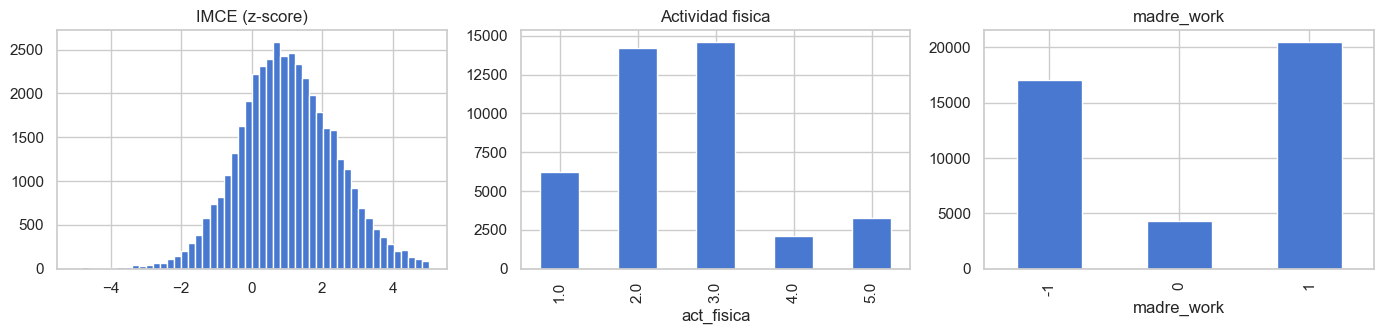

IMCE fuera de |z|>3: 3356 (8.02%) - puntajes z clinicamente validos, se conservan.


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
df['imce'].hist(bins=50, ax=ax[0]); ax[0].set_title('IMCE (z-score)')
df['act_fisica'].value_counts().sort_index().plot.bar(ax=ax[1]); ax[1].set_title('Actividad fisica')
df['madre_work'].value_counts().sort_index().plot.bar(ax=ax[2]); ax[2].set_title('madre_work')
plt.tight_layout(); plt.show()

# Outliers de IMCE (|z|>3)
out = (df['imce'].abs() > 3).sum()
print(f'IMCE fuera de |z|>3: {out} ({100*out/len(df):.2f}%) - puntajes z clinicamente validos, se conservan.')

### 1.C  Limpieza y recodificación

In [6]:
df_clean = df.copy()

# 1. Imputacion por mediana
for col in ['act_fisica', 'educm']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 2. Colapsar codigo 2 ("mas de un padre/madre") a presencia = 1
for col in ['vive_padre', 'vive_madre']:
    df_clean[col] = df_clean[col].replace({2: 1})

# 3. Reexpresion en sentido POSITIVO (mayor = conducta mas deseable).
#    sk1-sk6, sk8-sk13 estan codificadas 1:siempre -> 5:nunca para conductas
#    DESEABLES, por lo que se invierten con (6 - x) para que alto = mejor.
#    sk7 (agresivo) esta en sentido inverso (1:nunca -> 5:siempre) para una
#    conducta NO deseable; ahi alto valor crudo ya = mas agresion = peor, por
#    lo que NO se invierte: se deja crudo para que alto siga significando
#    "mas agresivo". Asi las 13 variables quedan en escala homogenea solo si se
#    interpreta sk7 como el unico item de polaridad negativa. Como sk7 resulta
#    no informativo (ver P2), esta distincion no afecta el EFA/CFA, pero se deja
#    explicita por correccion metodologica.
items_deseables = [c for c in sk_cols if c != 'sk7']
sk_pos = df_clean[sk_cols].astype(float).copy()
sk_pos[items_deseables] = 6 - sk_pos[items_deseables]
# sk7 se mantiene crudo (alto = mas agresivo). Queda como item de polaridad
# opuesta; el EFA lo identificara como no informativo.

print('NA tras imputacion:', int(df_clean[['act_fisica','educm']].isna().sum().sum()))
print('vive_padre:', df_clean['vive_padre'].value_counts().to_dict())
sk_pos.head(3)

NA tras imputacion: 0
vive_padre: {1: 30121, 0: 11733}


,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13
0,5.0000,5.0000,5.0000,4.0000,5.0000,4.0000,2.0000,5.0000,4.0000,4.0000,4.0000,3.0000,4.0000
1,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,4.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000
2,4.0000,4.0000,3.0000,4.0000,5.0000,4.0000,3.0000,4.0000,4.0000,3.0000,4.0000,5.0000,3.0000


---
## Pregunta 2 — Análisis Factorial Exploratorio (EFA)

### 2.A  Adecuación: KMO y Bartlett

In [7]:
kmo_all, kmo_model = calculate_kmo(sk_pos)
chi2_b, p_b = calculate_bartlett_sphericity(sk_pos)
print(f'KMO global = {kmo_model:.3f}  (>0.8 = meritorio)')
print(f'Bartlett: chi2 = {chi2_b:,.1f},  p = {p_b:.2e}')

KMO global = 0.873  (>0.8 = meritorio)
Bartlett: chi2 = 122,116.7,  p = 0.00e+00


### 2.B  Número óptimo de factores (Kaiser + scree)

Autovalores: [4.154 1.337 1.099 0.999 0.772 0.701 0.692 0.684 0.597 0.516 0.506 0.487
 0.456]
Factores con autovalor > 1 (Kaiser): 3


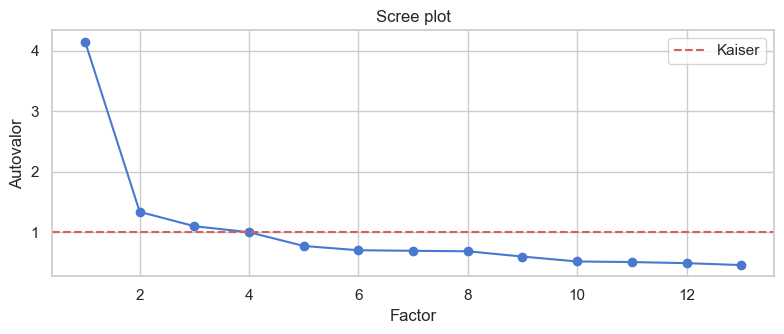

In [8]:
fa_full = FactorAnalyzer(rotation=None, n_factors=len(sk_cols))
fa_full.fit(sk_pos)
ev, _ = fa_full.get_eigenvalues()
n_factors = int((ev > 1).sum())
print('Autovalores:', np.round(ev, 3))
print(f'Factores con autovalor > 1 (Kaiser): {n_factors}')

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, len(ev)+1), ev, 'o-')
plt.axhline(1, color='r', ls='--', label='Kaiser')
plt.xlabel('Factor'); plt.ylabel('Autovalor'); plt.title('Scree plot'); plt.legend()
plt.tight_layout(); plt.show()

### 2.C  Loadings rotados (promax) y variable no informativa

In [9]:
fa = FactorAnalyzer(rotation='promax', n_factors=n_factors)
fa.fit(sk_pos)
loadings = pd.DataFrame(fa.loadings_, index=sk_cols,
                        columns=[f'F{i+1}' for i in range(n_factors)])
comm = pd.Series(fa.get_communalities(), index=sk_cols, name='comunalidad')
print('Factor loadings (promax):'); print(loadings.round(2), '\n')
print('Comunalidades:'); print(comm.round(3).to_string())
print(f'\n>>> Variable NO informativa: sk7 (comunalidad={comm["sk7"]:.3f}, '
      f'cargas <= {loadings.loc["sk7"].abs().max():.2f})')

Factor loadings (promax):
          F1      F2      F3
sk1   0.0200  0.6200 -0.0400
sk2  -0.0400  0.5100  0.2300
sk3   0.0200  0.6700 -0.0500
sk4  -0.0000  0.7500 -0.0300
sk5  -0.1600 -0.0200  0.8800
sk6   0.0100  0.0500  0.5200
sk7  -0.0200 -0.0300 -0.1400
sk8   0.1500 -0.1100  0.5200
sk9   0.5000  0.0900  0.0600
sk10  0.6200 -0.0300 -0.0300
sk11  0.7000  0.0400  0.0100
sk12  0.5800 -0.0300 -0.0000
sk13  0.5400  0.0200 -0.0200 

Comunalidades:
sk1    0.3820
sk2    0.3110
sk3    0.4460
sk4    0.5640
sk5    0.7970
sk6    0.2730
sk7    0.0200
sk8    0.3030
sk9    0.2560
sk10   0.3920
sk11   0.4870
sk12   0.3370
sk13   0.2940

>>> Variable NO informativa: sk7 (comunalidad=0.020, cargas <= 0.14)


In [10]:
print('Asignacion de items por carga dominante (|loading|>0.4):\n')
for f in loadings.columns:
    print(f'  {f}: {loadings.index[(loadings[f].abs() > 0.4)].tolist()}')

Asignacion de items por carga dominante (|loading|>0.4):

  F1: ['sk9', 'sk10', 'sk11', 'sk12', 'sk13']
  F2: ['sk1', 'sk2', 'sk3', 'sk4']
  F3: ['sk5', 'sk6', 'sk8']


---
## Pregunta 3 — Análisis Factorial Confirmatorio (CFA)

Estructura simple sobre los 12 ítems informativos. Se excluye `sk7` por su comunalidad nula en el EFA (no comparte varianza con ningún factor).

In [11]:
model_desc = '''
Afectivo  =~ sk1 + sk2 + sk3 + sk4
Social    =~ sk5 + sk6 + sk8
Cognitivo =~ sk9 + sk10 + sk11 + sk12 + sk13
'''
cfa = semopy.Model(model_desc)
cfa.fit(sk_pos)
stats = semopy.calc_stats(cfa)
print('Indices de ajuste:')
print(stats[['chi2', 'DoF', 'CFI', 'TLI', 'RMSEA']].round(3).to_string(index=False))

Indices de ajuste:
     chi2  DoF    CFI    TLI  RMSEA
6148.0960   51 0.9490 0.9340 0.0530


### 3.A  Importancia de cada medida (cargas estandarizadas)

In [12]:
fac = ['Afectivo', 'Social', 'Cognitivo']
ins = cfa.inspect(std_est=True)
# En esta version de semopy las cargas factoriales usan el operador '~'
# (item ~ factor), con el factor latente en la columna rval.
loads = ins[(ins['op'] == '~') & (ins['rval'].isin(fac))][['rval', 'lval', 'Est. Std', 'p-value']]
loads.columns = ['Factor', 'Item', 'Carga_std', 'p_value']
loads['Carga_std'] = loads['Carga_std'].astype(float).round(3)
print('Importancia de cada item a su factor (cargas estandarizadas):\n')
print(loads.sort_values(['Factor', 'Carga_std'], ascending=[True, False]).to_string(index=False))

Importancia de cada item a su factor (cargas estandarizadas):

   Factor Item  Carga_std p_value
 Afectivo  sk4     0.7150  0.0000
 Afectivo  sk2     0.6520  0.0000
 Afectivo  sk3     0.6460  0.0000
 Afectivo  sk1     0.6000       -
Cognitivo sk11     0.7360  0.0000
Cognitivo  sk9     0.6080       -
Cognitivo sk10     0.5650  0.0000
Cognitivo sk12     0.5510  0.0000
Cognitivo sk13     0.5230  0.0000
   Social  sk5     0.7230       -
   Social  sk6     0.5720  0.0000
   Social  sk8     0.5590  0.0000


### 3.B  Correlación entre factores

In [13]:
fac = ['Afectivo', 'Social', 'Cognitivo']
covs = ins[(ins['op'] == '~~') & (ins['lval'] != ins['rval'])]
covs = covs[covs['lval'].isin(fac) & covs['rval'].isin(fac)]
print(covs[['lval', 'rval', 'Est. Std']].round(3).to_string(index=False))

     lval      rval  Est. Std
Cognitivo  Afectivo    0.6120
   Social  Afectivo    0.6580
   Social Cognitivo    0.5960


### 3.C  Predicciones (scores factoriales) — se guardan para P4–P7

In [14]:
factor_scores = cfa.predict_factors(sk_pos)[fac]
factor_scores.columns = ['Afectivo', 'Social', 'Cognitivo']
factor_scores.to_csv('cfa_factor_scores.csv', index=False)
print('Scores guardados en cfa_factor_scores.csv')
print(factor_scores.describe().round(3))

Scores guardados en cfa_factor_scores.csv
        Afectivo     Social  Cognitivo
count 41854.0000 41854.0000 41854.0000
mean     -0.0000    -0.0000    -0.0000
std       0.2140     0.3560     0.3670
min      -2.0200    -3.0010    -2.7670
25%      -0.0660    -0.1510    -0.1790
50%       0.0840     0.1260     0.1120
75%       0.1450     0.2690     0.2750
max       0.1600     0.3080     0.3530


---
## Pregunta 4 — Random Forest (target `madre_work` binario)

**Siguiendo el enunciado, se excluye la categoría minoritaria `0` (desempleada)**, dejando un problema binario: labor doméstica (`-1`) vs empleada (`1`).

In [15]:
# Excluir desempleadas (clase 0) -> problema binario
keep = df_clean['madre_work'] != 0
X = factor_scores.loc[keep, ['Afectivo', 'Social', 'Cognitivo']].values
y = (df_clean.loc[keep, 'madre_work'] == 1).astype(int).values   # 1=empleada, 0=labor domestica

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'Observaciones tras excluir desempleadas: {len(y):,}')
print('Distribucion del target binario:', {'-1 (dom.)': int((y==0).sum()), '1 (empleada)': int((y==1).sum())})
print(f'Baseline mayoritario: {pd.Series(y).value_counts(normalize=True).max():.4f}')

Observaciones tras excluir desempleadas: 37,545
Distribucion del target binario: {'-1 (dom.)': 17026, '1 (empleada)': 20519}
Baseline mayoritario: 0.5465


In [16]:
rf_pipe = Pipeline([('rf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                                  class_weight='balanced'))])
rf_grid = {
    'rf__n_estimators':     [200, 400],
    'rf__max_depth':        [None, 6, 10],
    'rf__min_samples_leaf': [1, 5, 20],
}
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
t0 = time.time(); rf_search.fit(X, y); t_rf = time.time() - t0
print(f'Mejores hiperparametros: {rf_search.best_params_}')
print(f'Mejor macro-F1 (CV): {rf_search.best_score_:.4f}  |  tiempo: {t_rf:.1f}s')

Mejores hiperparametros: {'rf__max_depth': None, 'rf__min_samples_leaf': 20, 'rf__n_estimators': 200}
Mejor macro-F1 (CV): 0.5120  |  tiempo: 143.8s


In [17]:
best_rf = rf_search.best_estimator_
res = cross_validate(best_rf, X, y, cv=cv, scoring=['accuracy', 'f1_macro'], n_jobs=-1)
acc_rf, f1_rf = res['test_accuracy'].mean(), res['test_f1_macro'].mean()
print(f'Random Forest -> accuracy={acc_rf:.4f}  macro-F1={f1_rf:.4f}')
print(f'Baseline: {pd.Series(y).value_counts(normalize=True).max():.4f}\n')

y_pred = cross_val_predict(best_rf, X, y, cv=cv, n_jobs=-1)
print('Matriz de confusion (0=dom., 1=empleada):')
print(pd.DataFrame(confusion_matrix(y, y_pred),
                   index=['real_dom', 'real_emp'], columns=['pred_dom', 'pred_emp']))

Random Forest -> accuracy=0.5200  macro-F1=0.5120
Baseline: 0.5465

Matriz de confusion (0=dom., 1=empleada):
          pred_dom  pred_emp
real_dom      7607      9419
real_emp      8602     11917


---
## Pregunta 5 — XGBoost vs SVM vs Stacking

Mismo target binario y protocolo de CV. Se comparan los tres modelos contra el RF de la P4, con matriz de confusión y **tiempo de cómputo**.


In [18]:
def evaluate(name, estimator, X, y, cv):
    t0 = time.time()
    r = cross_validate(estimator, X, y, cv=cv, scoring=['accuracy', 'f1_macro'], n_jobs=-1)
    return {'modelo': name, 'accuracy': r['test_accuracy'].mean(),
            'macro_F1': r['test_f1_macro'].mean(), 'tiempo_s': time.time() - t0}

### 5.A  XGBoost — optimización de hiperparámetros

In [19]:
xgb_search = GridSearchCV(
    XGBClassifier(tree_method='hist', random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss'),
    {'n_estimators': [200, 400], 'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1, 0.2]},
    cv=cv, scoring='f1_macro', n_jobs=-1)
t0 = time.time(); xgb_search.fit(X, y); t_xgb = time.time() - t0
xgb = xgb_search.best_estimator_
print(f'XGBoost - mejores: {xgb_search.best_params_}')
print(f'macro-F1 CV: {xgb_search.best_score_:.4f}  |  tiempo: {t_xgb:.1f}s')

XGBoost - mejores: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 400}
macro-F1 CV: 0.4891  |  tiempo: 15.2s


### 5.B  SVM (RBF) — optimización de hiperparámetros

In [20]:
svm_search = GridSearchCV(
    Pipeline([('sc', StandardScaler()),
              ('svc', SVC(kernel='rbf', class_weight='balanced', cache_size=1000))]),
    {'svc__C': [0.1, 1.0, 10.0], 'svc__gamma': ['scale', 0.1]},
    cv=cv, scoring='f1_macro', n_jobs=-1)
t0 = time.time(); svm_search.fit(X, y); t_svm = time.time() - t0
svm = svm_search.best_estimator_
print(f'SVM - mejores: {svm_search.best_params_}')
print(f'macro-F1 CV: {svm_search.best_score_:.4f}  |  tiempo: {t_svm:.1f}s')

SVM - mejores: {'svc__C': 1.0, 'svc__gamma': 0.1}
macro-F1 CV: 0.4978  |  tiempo: 675.8s


### 5.C  Stacking (RF + XGBoost + SVM → meta-modelo logístico)

In [21]:
stack = StackingClassifier(
    estimators=[('rf', best_rf.named_steps['rf']), ('xgb', xgb), ('svm', svm)],
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=cv, n_jobs=-1)

### 5.D  Comparación: desempeño y eficiencia

In [22]:
rows = [{'modelo': 'RandomForest', 'accuracy': acc_rf, 'macro_F1': f1_rf, 'tiempo_s': t_rf}]
for name, est in [('XGBoost', xgb), ('SVM (RBF)', svm), ('Stacking', stack)]:
    rows.append(evaluate(name, est, X, y, cv))
comp = pd.DataFrame(rows).set_index('modelo')
print(comp.round(4).to_string())

              accuracy  macro_F1  tiempo_s
modelo                                    
RandomForest    0.5200    0.5120  143.8224
XGBoost         0.5328    0.4891    1.4242
SVM (RBF)       0.5390    0.4978  105.2792
Stacking        0.5281    0.5146  476.1763


### 5.E  Matrices de confusión

In [23]:
def matriz_conf(est, X, y, titulo):
    pred = cross_val_predict(est, X, y, cv=cv, n_jobs=-1)
    print(f'\n=== {titulo} ===')
    print(pd.DataFrame(confusion_matrix(y, pred),
                       index=['real_dom', 'real_emp'], columns=['pred_dom', 'pred_emp']))
    print(classification_report(y, pred, target_names=['dom.(-1)', 'empleada(1)']))

matriz_conf(xgb, X, y, 'XGBoost')
matriz_conf(svm, X, y, 'SVM (RBF)')
matriz_conf(stack, X, y, 'Stacking')


=== XGBoost ===
          pred_dom  pred_emp
real_dom      4516     12510
real_emp      5031     15488
              precision    recall  f1-score   support

    dom.(-1)       0.47      0.27      0.34     17026
 empleada(1)       0.55      0.75      0.64     20519

    accuracy                           0.53     37545
   macro avg       0.51      0.51      0.49     37545
weighted avg       0.52      0.53      0.50     37545


=== SVM (RBF) ===
          pred_dom  pred_emp
real_dom      4751     12275
real_emp      5032     15487
              precision    recall  f1-score   support

    dom.(-1)       0.49      0.28      0.35     17026
 empleada(1)       0.56      0.75      0.64     20519

    accuracy                           0.54     37545
   macro avg       0.52      0.52      0.50     37545
weighted avg       0.53      0.54      0.51     37545


=== Stacking ===
          pred_dom  pred_emp
real_dom      6784     10242
real_emp      7476     13043
              precision    reca

**Discusión.** Con el target binario los modelos quedan próximos al baseline (~0.55 de accuracy) y un macro-F1 más alto que en un planteamiento de 3 clases (al estar más balanceado). En eficiencia, XGBoost es el más rápido; el SVM-RBF y el Stacking son sustancialmente más costosos (el SVM escala $\sim O(n^2)$). La señal de los tres scores factoriales sobre el empleo materno sigue siendo limitada: el cuello de botella es la información disponible, no el algoritmo.

---
## Pregunta 6 — Clustering (`imce` × `act_fisica`)

In [24]:
clu_data = df_clean[['imce', 'act_fisica']].copy()
clu_scaled = StandardScaler().fit_transform(clu_data)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(clu_scaled),
                                                        min(5000, len(clu_scaled)), replace=False)
print('Silhouette por numero de clusters:')
for kk in [2, 3, 4, 5]:
    km = KMeans(n_clusters=kk, random_state=RANDOM_STATE, n_init=10).fit(clu_scaled)
    print(f'  k={kk}: {silhouette_score(clu_scaled[sample_idx], km.labels_[sample_idx]):.3f}')

Silhouette por numero de clusters:
  k=2: 0.344
  k=3: 0.376
  k=4: 0.379
  k=5: 0.370


          imce  act_fisica      n
cluster                          
0       0.0030      2.2320  19595
1       2.2170      2.2390  17026
2       0.8860      4.6240   5233


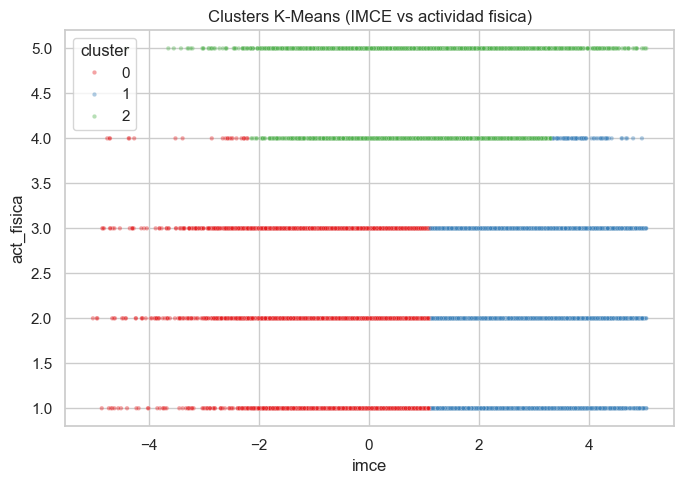

In [25]:
k_opt = 3
km = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10).fit(clu_scaled)
df_clean['cluster'] = km.labels_
resumen = df_clean.groupby('cluster')[['imce', 'act_fisica']].mean()
resumen['n'] = df_clean['cluster'].value_counts().sort_index()
print(resumen.round(3).to_string())

plt.figure(figsize=(7, 5))
sns.scatterplot(x=df_clean['imce'], y=df_clean['act_fisica'],
                hue=df_clean['cluster'], palette='Set1', s=10, alpha=0.4)
plt.title('Clusters K-Means (IMCE vs actividad fisica)')
plt.tight_layout(); plt.show()

**Conclusión.** El silhouette es máximo en $k=4$ (0.379) pero apenas supera a $k=3$ (0.376), por lo que se opta por **3 clusters** (más parsimonioso e interpretable). Los grupos se separan principalmente por **IMCE**, con la **actividad física** aislando al grupo activo:

- **Cluster 0** (n = 19.595): IMCE normal (≈ 0.00) y actividad baja (≈ 2.2). Grupo modal.
- **Cluster 1** (n = 17.026): **IMCE alto (≈ 2.22)** y actividad baja (≈ 2.2). Perfil de **riesgo** (sobrepeso con poca actividad).
- **Cluster 2** (n = 5.233): IMCE moderado (≈ 0.89) y **actividad alta (≈ 4.6)**. Estudiantes activos.

El patrón es coherente con la evidencia en salud: el subgrupo con mayor IMCE coincide con baja actividad física, mientras que los más activos no alcanzan los IMCE extremos. La actividad física, aunque secundaria en la partición, es lo que diferencia al cluster 2 del resto a IMCE comparable.

---
## Pregunta 7 — Mejor modelo de P5 sobre el grupo de mayor IMCE

Se elige el cluster de mayor IMCE promedio y se reestima el **mejor modelo de la P5** (por macro-F1) sobre ese subgrupo, con el mismo target binario.

In [26]:
high_imce_cluster = resumen['imce'].idxmax()
print(f'Cluster de mayor IMCE: {high_imce_cluster} (IMCE={resumen.loc[high_imce_cluster,"imce"]:.3f})')

# Subgrupo, manteniendo la exclusion de desempleadas (target binario)
mask_sub = (df_clean['cluster'] == high_imce_cluster) & (df_clean['madre_work'] != 0)
X_sub = factor_scores.loc[mask_sub, ['Afectivo', 'Social', 'Cognitivo']].values
y_sub = (df_clean.loc[mask_sub, 'madre_work'] == 1).astype(int).values
print(f'Tamano del subgrupo: {mask_sub.sum():,}')
print('Distribucion:', {'-1': int((y_sub==0).sum()), '1': int((y_sub==1).sum())})

best_p5_name = comp.loc[['XGBoost', 'SVM (RBF)', 'Stacking']]['macro_F1'].idxmax()
print(f'Mejor modelo de la P5 (por macro-F1): {best_p5_name}')

Cluster de mayor IMCE: 1 (IMCE=2.217)
Tamano del subgrupo: 15,225
Distribucion: {'-1': 6725, '1': 8500}
Mejor modelo de la P5 (por macro-F1): Stacking


In [27]:
cv_sub = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
if best_p5_name == 'XGBoost':
    best_model = GridSearchCV(
        XGBClassifier(tree_method='hist', random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss'),
        {'n_estimators': [200, 400], 'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1, 0.2]},
        cv=cv_sub, scoring='f1_macro', n_jobs=-1)
elif best_p5_name == 'SVM (RBF)':
    best_model = GridSearchCV(
        Pipeline([('sc', StandardScaler()),
                  ('svc', SVC(kernel='rbf', class_weight='balanced', cache_size=1000))]),
        {'svc__C': [0.1, 1.0, 10.0], 'svc__gamma': ['scale', 0.1]},
        cv=cv_sub, scoring='f1_macro', n_jobs=-1)
else:
    best_model = stack

res_sub = cross_validate(best_model, X_sub, y_sub, cv=cv_sub,
                         scoring=['accuracy', 'f1_macro'], n_jobs=-1)
print(f'{best_p5_name} sobre cluster de mayor IMCE:')
print(f'  accuracy = {res_sub["test_accuracy"].mean():.4f}')
print(f'  macro-F1 = {res_sub["test_f1_macro"].mean():.4f}')
print(f'  baseline = {pd.Series(y_sub).value_counts(normalize=True).max():.4f}')

Stacking sobre cluster de mayor IMCE:
  accuracy = 0.5373
  macro-F1 = 0.5137
  baseline = 0.5583


**Conclusión.** Sobre el cluster de mayor IMCE (15.225 obs.), el mejor modelo de la P5 (**Stacking**) da accuracy 0.537 y macro-F1 0.514, por debajo del baseline del subgrupo (0.558) y en línea con la muestra completa. Restringir al subgrupo de riesgo **no** revela una relación latente: la débil asociación entre habilidades socioemocionales y empleo materno es **robusta** y no un artefacto de mezclar subpoblaciones con distinto IMC.

---
## Pregunta 8 — Clasificación de texto (SVC) siguiendo `Sentiment_Analysis.ipynb`

Se replica el flujo del notebook de referencia: **función de tokenización** (regex + stopwords español de NLTK), **CountVectorizer** y un **SVC**, sobre el target binario y **excluyendo las variables `sk`**, para contrastar con la P5.

### 8.A  Función de tokenización (adaptada del notebook de referencia)

In [28]:
stops_es = set(stopwords.words('spanish'))

def text_to_words(texto):
    '''Limpieza + tokenizacion al estilo de Sentiment_Analysis.ipynb.'''
    letters_only = re.sub(r'#([A-Za-z_À-ÿ]+)', ' ', str(texto))
    words = letters_only.lower().split()
    meaningful = [w for w in words if w not in stops_es]
    return ' '.join(meaningful)

# Se trabaja con las mismas observaciones del problema binario (excluye desempleadas)
data_txt = df_clean.loc[keep].copy()
data_txt['clean_text'] = data_txt[TEXT_COL].apply(text_to_words)
y_txt = (data_txt['madre_work'] == 1).astype(int).values
print('Ejemplo de texto tokenizado:')
print(data_txt['clean_text'].iloc[0][:200])

Ejemplo de texto tokenizado:
plano afectivo emocional, dimension encuentra desarrollada, manifestandose manera constante: muestra afecto hacia padres siempre, hacia pares siempre, expresa sentimientos siempre recurre casi siempre


### 8.B  Vectorización (CountVectorizer) y split 80/20

In [29]:
x_train, x_test, y_train, y_test = train_test_split(
    data_txt['clean_text'], y_txt, test_size=0.2, random_state=RANDOM_STATE, stratify=y_txt)

# Funcion de tokenizacion del notebook de referencia + vocabulario ampliado
# para obtener un clasificador adecuado (el enunciado pide "un modelo adecuado").
vect = CountVectorizer(ngram_range=(1, 2), min_df=5, max_features=300)
vect.fit(x_train)
x_train_dtm = vect.transform(x_train)
x_test_dtm = vect.transform(x_test)
print(f'Vocabulario: {len(vect.get_feature_names_out())} features')
print(f'Train: {x_train_dtm.shape}  Test: {x_test_dtm.shape}')

Vocabulario: 300 features
Train: (30036, 300)  Test: (7509, 300)


### 8.C  Modelo SVM lineal (LinearSVC) y evaluación

SVC (texto) - accuracy = 0.5415  |  tiempo: 7.2s
Baseline: 0.5465



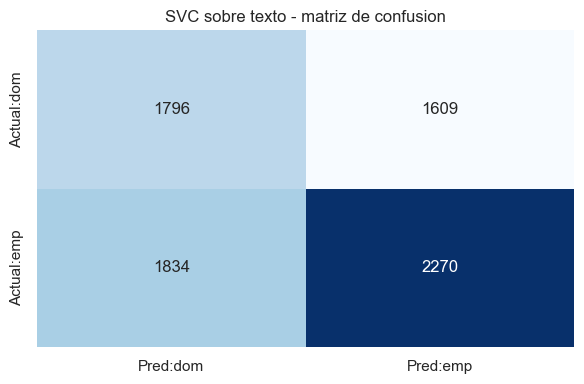

              precision    recall  f1-score   support

    dom.(-1)       0.49      0.53      0.51      3405
 empleada(1)       0.59      0.55      0.57      4104

    accuracy                           0.54      7509
   macro avg       0.54      0.54      0.54      7509
weighted avg       0.54      0.54      0.54      7509



In [30]:
from sklearn.svm import LinearSVC
model = LinearSVC(random_state=10, class_weight='balanced', max_iter=5000)
t0 = time.time(); model.fit(x_train_dtm, y_train); t_txt = time.time() - t0
pred = model.predict(x_test_dtm)

acc_txt = accuracy_score(y_test, pred)
print(f'SVC (texto) - accuracy = {acc_txt:.4f}  |  tiempo: {t_txt:.1f}s')
print(f'Baseline: {pd.Series(y_test).value_counts(normalize=True).max():.4f}\n')

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 4))
sns.heatmap(pd.DataFrame(cm, index=['Actual:dom', 'Actual:emp'],
                         columns=['Pred:dom', 'Pred:emp']),
            annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('SVC sobre texto - matriz de confusion'); plt.tight_layout(); plt.show()

print(classification_report(y_test, pred, target_names=['dom.(-1)', 'empleada(1)']))

### 8.D  Coeficientes del SVC lineal (palabras más informativas)

In [31]:
dfout = pd.DataFrame(vect.get_feature_names_out(), columns=['feature'])
dfout['coef'] = model.coef_[0]   # LinearSVC: coef_ ya es denso
dfout = dfout.sort_values('coef', ascending=False)
print('Tokens con mayor peso hacia "empleada" (coef alto) y "dom." (coef bajo):')
print(pd.concat([dfout.head(8), dfout.tail(8)]).to_string(index=False))

Tokens con mayor peso hacia "empleada" (coef alto) y "dom." (coef bajo):
               feature    coef
        constante hace  0.1795
   ambito desarrollada  0.1795
           ambito bien  0.1744
        frecuente hace  0.1744
         pares aspecto  0.1475
             vez juega  0.1369
          entorno rara  0.1369
        ambito proceso  0.1254
    frecuentes muestra -0.1484
  encuentra incipiente -0.1484
     encuentra proceso -0.2154
  intermitente muestra -0.2154
encuentra desarrollada -0.2807
     constante muestra -0.2807
     frecuente muestra -0.2854
        encuentra bien -0.2854


### 8.E  Contraste con la Pregunta 5

In [32]:
print('Contraste P8 (texto, SVC) vs P5 (scores CFA):')
print(f'  SVC sobre TEXTO (P8):        accuracy = {acc_txt:.4f}')
print(f'  SVM (RBF) sobre scores (P5): accuracy = {comp.loc["SVM (RBF)","accuracy"]:.4f}  '
      f'macro-F1 = {comp.loc["SVM (RBF)","macro_F1"]:.4f}')
print(f'  Mejor modelo P5 ({best_p5_name}): accuracy = {comp.loc[best_p5_name,"accuracy"]:.4f}')
print(f'  Baseline: {pd.Series(y_txt).value_counts(normalize=True).max():.4f}')

Contraste P8 (texto, SVC) vs P5 (scores CFA):
  SVC sobre TEXTO (P8):        accuracy = 0.5415
  SVM (RBF) sobre scores (P5): accuracy = 0.5390  macro-F1 = 0.4978
  Mejor modelo P5 (Stacking): accuracy = 0.5281
  Baseline: 0.5465


**Discusión.** El SVM lineal sobre la narrativa tokenizada da accuracy 0.541, casi igual al baseline (0.547) y al mejor modelo de la P5 (SVM-RBF 0.539, Stacking 0.528). Con 300 términos el modelo **sí discrimina** (precision/recall equilibrados, macro-F1 0.54) y permite interpretar coeficientes: bigramas como "constante hace" o "ambito desarrollada" empujan hacia *empleada*, mientras que "frecuente muestra" o "encuentra bien" empujan hacia *labor doméstica*. Aun así, el desempeño confirma el hallazgo de la P5: la narrativa es una **paráfrasis determinista** de los ítems `sk1`–`sk13` y no añade señal nueva sobre `madre_work`. El valor es metodológico: implementa el flujo de NLP de referencia (tokenización, `CountVectorizer`, SVM lineal, matriz de confusión, coeficientes) y lo contrasta con los modelos tabulares de la P5.